In [ ]:
!pip install transformers torch -q

import torch
import torch.nn as nn
from transformers import DistilBertModel, DistilBertTokenizer
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"\nUsing device: {'GPU' if torch.cuda.is_available() else 'CPU'}")


Using device: GPU


#LOADING DATA

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

path = "/content/drive/MyDrive/Intent-clf/data_final.csv"
df = pd.read_csv(path)
df.head()

print(f"\nLoaded {len(df)} examples")
print(f"Categories: {df['intent'].unique()}")
print("\nDistribution:")
print(df["intent"].value_counts())

# label map
intent_to_id = {intent: idx for idx, intent in enumerate(df["intent"].unique())}
id_to_intent = {idx: intent for intent, idx in intent_to_id.items()}

print(f"\nLabel mapping:")
for intent, idx in intent_to_id.items():
    print(f"{intent} -> {idx}")

#number columns
df["label"] = df["intent"].map(intent_to_id)

#split
train_df, test_df = train_test_split(
    df,
    test_size=0.2, #20 for test
    random_state=42,
    stratify=df["intent"] # balancing
)

print(f"\nTraining examples: {len(train_df)}")
print(f"Testing examples: {len(test_df)}")
print(f"Number of categories: {len(intent_to_id)}")

Mounted at /content/drive

Loaded 1865 examples
Categories: ['celebrating' 'struggling' 'grateful' 'questioning' 'ending' 'neutral']

Distribution:
intent
struggling     356
celebrating    351
questioning    314
grateful       299
neutral        279
ending         266
Name: count, dtype: int64

Label mapping:
celebrating -> 0
struggling -> 1
grateful -> 2
questioning -> 3
ending -> 4
neutral -> 5

Training examples: 1492
Testing examples: 373
Number of categories: 6


# TOKENIZER

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

print("\nTokenizing training data.")
train_encodings = tokenizer(
    train_df["text"].tolist(),
    max_length=256,
    padding="max_length",
    truncation=True,
    return_tensors="pt")

print("Tokenizing test data.")
test_encodings = tokenizer(
    test_df["text"].tolist(),
    max_length=256,
    padding="max_length", #data has very different lenghts
    truncation=True,
    return_tensors="pt")

#label to tensor
train_labels = torch.tensor(train_df["label"].values, dtype=torch.long)
test_labels = torch.tensor(test_df["label"].values, dtype=torch.long)

# tensordataset
train_dataset = TensorDataset(
    train_encodings["input_ids"],
    train_encodings["attention_mask"],
    train_labels)

test_dataset = TensorDataset(
    test_encodings["input_ids"],
    test_encodings["attention_mask"],
    test_labels)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True)  #shuffle for training


test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)  #no shuffle for test


print("ok")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizing training data.
Tokenizing test data.
ok


# NEURAL NETWORKS

In [ ]:
class CustomIntentClassifier(nn.Module):
    """
    NN for intent clf

    Architecture:
    DistilBERT for feature extraction
    4 Layers
    ReLU activation
    Batch Normalization
    Dropout for regularization
    """

    def __init__(self, num_classes, dropout_rate=0.3):
        super(CustomIntentClassifier, self).__init__()

        # pretrained distilbert
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")

        for param in self.bert.parameters():
            param.requires_grad = False


        # i added 4 custom layers each getting smaller

        #layers
        self.dropout1 = nn.Dropout(dropout_rate) # dropout to prevent overfitting

        #layer 1
        self.fc1 = nn.Linear(768, 512)
        self.relu1 = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(dropout_rate)

        #layer 2
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(dropout_rate)

        #layer 3
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout4 = nn.Dropout(dropout_rate)

        self.fc4 = nn.Linear(128, num_classes)

    def forward(self, input_ids, attention_mask):
        """Pass through the network. Using bert features to understand and layers to classify. """

        #features from BERT
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]

        #passing through layers
        x = self.dropout1(pooled_output)

        x = self.fc1(x)
        x = self.relu1(x)
        x = self.bn1(x)
        x = self.dropout2(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.bn2(x)
        x = self.dropout3(x)

        x = self.fc3(x)
        x = self.relu3(x)
        x = self.bn3(x)
        x = self.dropout4(x)

        logits = self.fc4(x)

        return logits

class ManifestationJournalClassifier:
    """
    Wraps the neural network + rule-based overrides
    !!WIP!!
    """

    def __init__(self, model, tokenizer, intent_to_id, id_to_intent, device):
        self.model = model
        self.tokenizer = tokenizer
        self.intent_to_id = intent_to_id
        self.id_to_intent = id_to_intent
        self.device = device
        self.model.eval()

    def _apply_rules(self, text, model_prediction, confidence):
        """Applys rules for suicide keywords and slang"""

        # at the start i used way more rules but they were hurting the performance and since i will change the training data later i thought they were unnecessary for now so these are just like a preview for now.
        text_lower = text.lower().strip()

        # mental health keywords (i might treat them differently later)
        suicide_keywords = [
            "kms", "kill myself", "end it all", "wanna die",
            "want to die", "no reason to live"
        ]

        for keyword in suicide_keywords:
            if keyword in text_lower:
                return "struggling", 0.95, True

        #treating exact matches

        exact_matches = {
            # Celebrating
            "omg": ("celebrating", 0.90),
            "yesss": ("celebrating", 0.90),
            "lets fucking go": ("celebrating", 0.92),
            "fuck yeah": ("celebrating", 0.92),
            "slay": ("celebrating", 0.88),
            "w": ("celebrating", 0.85),

            # Neutral
            "lmao": ("neutral", 0.80),
            "lol": ("neutral", 0.80),
            "bruh": ("neutral", 0.75),

            # Ending
            "bye": ("ending", 0.92),
            "gtg": ("ending", 0.92),
            "ttyl": ("ending", 0.92),
            "gn": ("ending", 0.90),
            "nvm": ("ending", 0.85),

            # Struggling
            "ugh": ("struggling", 0.80),
        }

        if text_lower in exact_matches:
            intent, conf = exact_matches[text_lower]
            return intent, conf, True

        #negative overrides

        if model_prediction == "celebrating":
            obvious_negatives = [
                "i hate", "hate this", "nothing works", "always fails",
                "cant even", "so done", "fuck this"
            ]

            for neg in obvious_negatives:
                if neg in text_lower:
                    return "struggling", 0.80, True

        #doubt phrases

        if text_lower.startswith("what if "):
            if model_prediction != "struggling":
                return "struggling", 0.78, True


        return model_prediction, confidence, False

    def predict(self, text):
        """Predict intent for a given text"""

        encoding = self.tokenizer(
            text,
            max_length=256,
            padding="max_length",
            truncation=True,
            return_tensors="pt")

        input_ids = encoding["input_ids"].to(self.device)
        attention_mask = encoding["attention_mask"].to(self.device)

        with torch.no_grad():
            logits = self.model(input_ids, attention_mask)
            probs = torch.nn.functional.softmax(logits, dim=-1)
            predicted_class = torch.argmax(probs, dim=-1).item()
            model_confidence = probs[0][predicted_class].item()

        model_intent = self.id_to_intent[predicted_class]

        final_intent, final_confidence, rule_applied = self._apply_rules(
            text, model_intent, model_confidence)

        return {
            "text": text,
            "intent": final_intent,
            "confidence": final_confidence,
            "model_prediction": model_intent,
            "model_confidence": model_confidence,
            "rule_override": rule_applied}

    def save(self, save_dir):
        import os

        os.makedirs(save_dir, exist_ok=True)

        torch.save({
            "model_state_dict": self.model.state_dict(),
            "intent_to_id": self.intent_to_id,
            "id_to_intent": self.id_to_intent,
            "num_classes": len(self.intent_to_id),
            "dropout_rate": 0.3
        }, f"{save_dir}/model.pt")

        self.tokenizer.save_pretrained(f"{save_dir}/tokenizer")
        print(f"Complete classifier saved to: {save_dir}")

    @classmethod
    def load(cls, save_dir, device):
        tokenizer = DistilBertTokenizer.from_pretrained(f"{save_dir}/tokenizer")
        checkpoint = torch.load(f"{save_dir}/model.pt", map_location=device)

        model = CustomIntentClassifier(
            num_classes=checkpoint["num_classes"],
            dropout_rate=checkpoint["dropout_rate"]
        )
        model.load_state_dict(checkpoint["model_state_dict"])
        model = model.to(device)
        model.eval()

        classifier = cls(
            model=model,
            tokenizer=tokenizer,
            intent_to_id=checkpoint["intent_to_id"],
            id_to_intent=checkpoint["id_to_intent"],
            device=device
        )

        print(f"Complete classifier loaded from: {save_dir}")
        return classifier

In [ ]:
# creating the model

num_classes = len(intent_to_id)
dropout_rate = 0.3

model = CustomIntentClassifier(
    num_classes=num_classes,
    dropout_rate=dropout_rate)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# training configirations here

learning_rate = 0.001
num_epochs = 7 #i tested multiple ones, 7 was the best without overfitting so for further experimentations i set it to 7 and left like that
weight_decay = 0.01

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,)

print("Training configs are set.")

Training configs are set.


In [ ]:
#training

print("Starting training")
print("#" * 30)

train_losses = []
test_losses = []
train_accs = []
test_accs = []

best_test_acc = 0
best_epoch = 0
best_model_state = None

for epoch in range(num_epochs):

    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch in train_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    #validation
    model.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            test_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss /= len(test_loader)
    test_acc = test_correct / test_total

    scheduler.step(test_loss)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    #saving the best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_model_state = model.state_dict().copy()

    #printing loss
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} ## Test Loss: {test_loss:.4f}")

#loading best model
model.load_state_dict(best_model_state)

print("\ntraining completed")
print("#" * 30)
print(f"Best model from epoch {best_epoch}")
print(f"Best Test Accuracy: {best_test_acc*100:.2f}%")

Starting training
##############################
Epoch 1/7 - Train Loss: 1.3986 ## Test Loss: 0.7699
Epoch 2/7 - Train Loss: 0.8396 ## Test Loss: 0.5508
Epoch 3/7 - Train Loss: 0.6735 ## Test Loss: 0.4957
Epoch 4/7 - Train Loss: 0.6483 ## Test Loss: 0.4863
Epoch 5/7 - Train Loss: 0.6483 ## Test Loss: 0.4788
Epoch 6/7 - Train Loss: 0.5983 ## Test Loss: 0.4678
Epoch 7/7 - Train Loss: 0.6009 ## Test Loss: 0.4381

training completed
##############################
Best model from epoch 7
Best Test Accuracy: 85.79%


In [ ]:
#full clf

classifier = ManifestationJournalClassifier(
    model=model,
    tokenizer=tokenizer,
    intent_to_id=intent_to_id,
    id_to_intent=id_to_intent,
    device=device)

print("Full clf created")

#save
save_dir = "/content/drive/MyDrive/Intent-clf/complete_classifier"
classifier.save(save_dir)

Full clf created
Complete classifier saved to: /content/drive/MyDrive/Intent-clf/complete_classifier


# EVAL

running evals

METRICS:
##############################

Test Accuracy: 85.25%
Precision: 0.854
Recall: 0.853
F1-Score: 0.852

Average Confidence: 82.9%
Rule Overrides: 6/373 (1.6%)

PERFORMANCE BY CATEGORY:
##############################

              precision    recall  f1-score   support

 celebrating      0.740     0.771     0.755        70
  struggling      0.869     0.746     0.803        71
    grateful      0.862     0.933     0.896        60
 questioning      0.931     0.857     0.893        63
      ending      0.895     0.962     0.927        53
     neutral      0.847     0.893     0.870        56

    accuracy                          0.853       373
   macro avg      0.857     0.861     0.857       373
weighted avg      0.854     0.853     0.852       373


CONFUSION MATRIX:
##############################


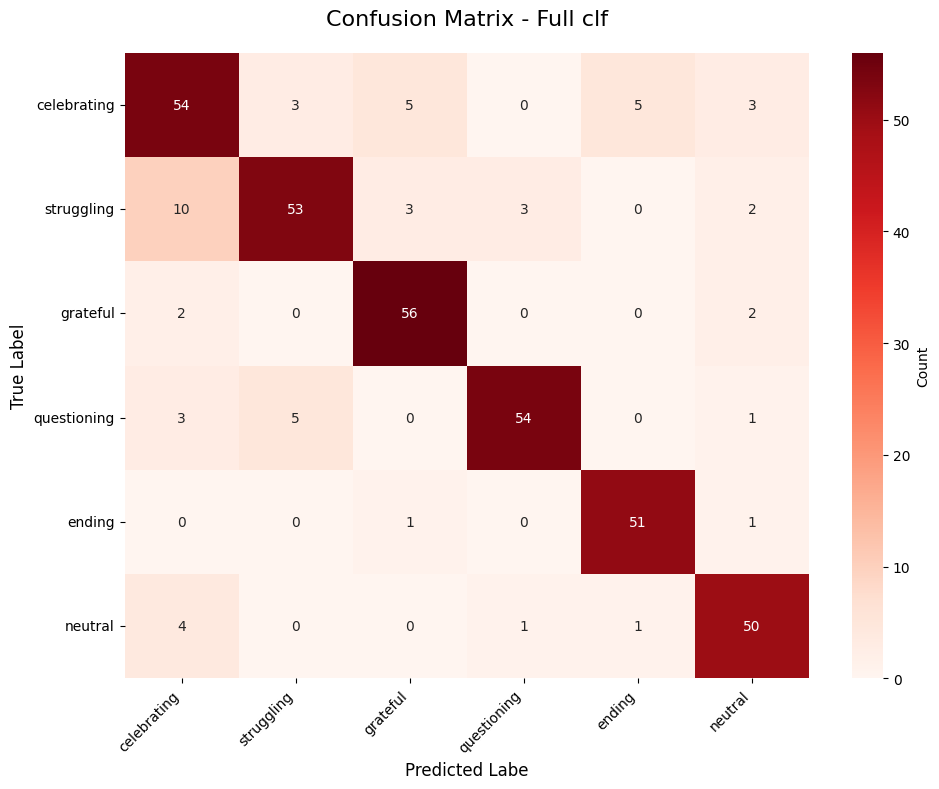


CONFIDENCE ANALYSIS:
##############################

Correct Predictions: 318/373 (85.3%)
Avg confidence: 86.3%
Min confidence: 27.5%
Max confidence: 100.0%

Incorrect Predictions: 55/373 (14.7%)
Avg confidence: 63.2%
Min confidence: 24.5%
Max confidence: 96.8%


/tmp/ipykernel_456/219333801.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=["Correct", "Incorrect"], patch_artist=True)


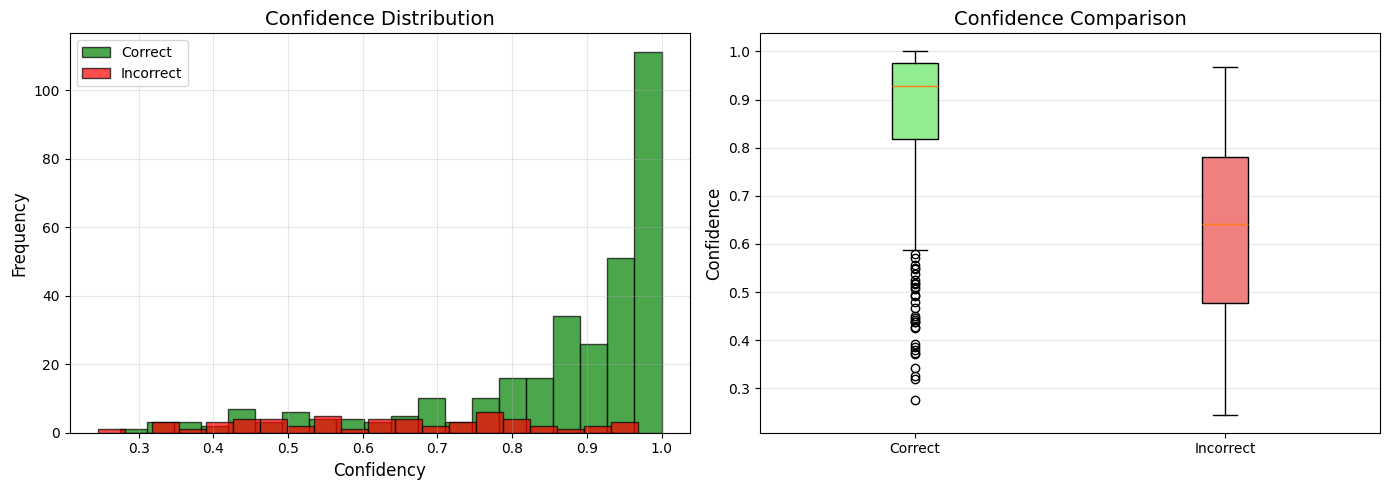


ERROR ANALYSIS:
##############################

Showing top 10 most confident mistakes:

1. True: celebrating | Predicted: struggling (96.8%) Model
   'he cant stop thinking about me'

2. True: questioning | Predicted: celebrating (93.8%) Model
   'Husband cheated for 8 months, contracted STD. We have 2 kids, 10-year marriage. What now?'

3. True: struggling | Predicted: questioning (93.3%) Model
   'can something just go right for once?? please??'

4. True: celebrating | Predicted: ending (91.7%) Model
   'the check cleared 😭😭😭 thank u universe i forgive u (for now)'

5. True: grateful | Predicted: celebrating (91.3%) Model
   'Today while delivering Meals on Wheels a super sweet senior told me he thought I was pretty, and cal...'

6. True: neutral | Predicted: celebrating (87.3%) Model
   'awesome story, crazy good cinematography, incredible acting. It 100% should have had more seasons. I...'

7. True: celebrating | Predicted: ending (85.9%) Model
   'wooo my bestie is coming to vis

In [ ]:
print("running evals")

all_predictions = []
all_true_labels = []
all_confidences = []
rule_override_count = 0

for text, true_label in zip(test_df["text"].values, test_df["label"].values):
    result = classifier.predict(text)

    predicted_label = intent_to_id[result["intent"]]

    all_predictions.append(predicted_label)
    all_true_labels.append(true_label)
    all_confidences.append(result["confidence"])

    if result["rule_override"]:
        rule_override_count += 1

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)
all_confidences = np.array(all_confidences)

#metrics
accuracy = accuracy_score(all_true_labels, all_predictions)
precision, recall, f1, support = precision_recall_fscore_support(
    all_true_labels,
    all_predictions,
    average="weighted"
)

print("\nMETRICS:")
print("#" * 30)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"\nAverage Confidence: {all_confidences.mean()*100:.1f}%")
print(f"Rule Overrides: {rule_override_count}/{len(test_df)} ({rule_override_count/len(test_df)*100:.1f}%)")

#category based performance

print("\nPERFORMANCE BY CATEGORY:")
print("#" * 30)
print()

report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=list(intent_to_id.keys()),
    digits=3
)
print(report)

#confusion matrix

print("\nCONFUSION MATRIX:")
print("#" * 30)

cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=intent_to_id.keys(),
    yticklabels=intent_to_id.keys(),
    cbar_kws={"label": "Count"}
)
plt.title("Confusion Matrix - Full clf", fontsize=16, pad=20)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Labe", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Intent-clf/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

#confidence analysis

print("\nCONFIDENCE ANALYSIS:")
print("#" * 30)

correct_mask = (all_predictions == all_true_labels)
incorrect_mask = ~correct_mask
correct_confidences = all_confidences[correct_mask]
incorrect_confidences = all_confidences[incorrect_mask]

print(f"\nCorrect Predictions: {correct_mask.sum()}/{len(test_df)} ({correct_mask.sum()/len(test_df)*100:.1f}%)")
print(f"Avg confidence: {correct_confidences.mean()*100:.1f}%")
print(f"Min confidence: {correct_confidences.min()*100:.1f}%")
print(f"Max confidence: {correct_confidences.max()*100:.1f}%")

print(f"\nIncorrect Predictions: {incorrect_mask.sum()}/{len(test_df)} ({incorrect_mask.sum()/len(test_df)*100:.1f}%)")
if len(incorrect_confidences) > 0:
    print(f"Avg confidence: {incorrect_confidences.mean()*100:.1f}%")
    print(f"Min confidence: {incorrect_confidences.min()*100:.1f}%")
    print(f"Max confidence: {incorrect_confidences.max()*100:.1f}%")

#plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#hisyogram
ax1.hist(correct_confidences, bins=20, alpha=0.7, label= "Correct", color="green", edgecolor="black")
ax1.hist(incorrect_confidences, bins=20, alpha=0.7, label="Incorrect", color="red", edgecolor="black")
ax1.set_xlabel("Confidency", fontsize=12)
ax1.set_ylabel("Frequency", fontsize=12)
ax1.set_title("Confidence Distribution", fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

#boxplot
box_data = [correct_confidences, incorrect_confidences]
bp = ax2.boxplot(box_data, labels=["Correct", "Incorrect"], patch_artist=True)
bp["boxes"][0].set_facecolor("lightgreen")
bp["boxes"][1].set_facecolor("lightcoral")
ax2.set_ylabel("Confidence", fontsize=12)
ax2.set_title("Confidence Comparison", fontsize=14)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Intent-clf/confidence_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

#error analysis

print("\nERROR ANALYSIS:")
print("#" * 30)

#where model was very confident but wrong
if len(incorrect_confidences) > 0:
    error_indices = np.where(incorrect_mask)[0]
    error_confidences = all_confidences[incorrect_mask]

    sorted_error_indices = error_indices[np.argsort(error_confidences)[::-1]]

    print(f"\nShowing top 10 most confident mistakes:\n")

    for i, idx in enumerate(sorted_error_indices[:10], 1):
        text = test_df.iloc[idx]['text']
        true_intent = id_to_intent[all_true_labels[idx]]
        pred_intent = id_to_intent[all_predictions[idx]]
        confidence = all_confidences[idx]

        result = classifier.predict(text)
        rule_used = "Rule" if result["rule_override"] else "Model"

        print(f"{i}. True: {true_intent} | Predicted: {pred_intent} ({confidence*100:.1f}%) {rule_used}")
        print(f"   '{text[:100]}{'...' if len(text) > 100 else ''}'")
        print()

# metrics to txt

metrics_file = "/content/drive/MyDrive/Intent-clf/evaluation_metrics.txt"
with open(metrics_file, "w") as f:
    f.write("#" * 60 + "\n")
    f.write("Intent Classification Eval Results\n")
    f.write("#" * 60 + "\n\n")

    f.write(f"Test Accuracy: {accuracy*100:.2f}%\n")
    f.write(f"Precision: {precision:.3f}\n")
    f.write(f"Recall: {recall:.3f}\n")
    f.write(f"F1-Score: {f1:.3f}\n\n")

    f.write(f"Average Confidence: {all_confidences.mean()*100:.1f}%\n")
    f.write(f"Rule Overrides: {rule_override_count}/{len(test_df)} ({rule_override_count/len(test_df)*100:.1f}%)\n\n")

    f.write("#" * 60 + "\n")
    f.write("PER-CLASS PERFORMANCE\n")
    f.write("#" * 60 + "\n\n")
    f.write(report)

    f.write("\n" + "#" * 60 + "\n")
    f.write("CONFIDENCE ANALYSIS\n")
    f.write("#" * 60 + "\n\n")

    f.write(f"Correct Predictions:\n")
    f.write(f"Count: {correct_mask.sum()}/{len(test_df)} ({correct_mask.sum()/len(test_df)*100:.1f}%)\n")
    f.write(f"Avg Confidence: {correct_confidences.mean()*100:.1f}%\n")
    f.write(f"Min Confidence: {correct_confidences.min()*100:.1f}%\n")
    f.write(f"Max Confidence: {correct_confidences.max()*100:.1f}%\n\n")

    if len(incorrect_confidences) > 0:
        f.write(f"Incorrect Predictions:\n")
        f.write(f"Count: {incorrect_mask.sum()}/{len(test_df)} ({incorrect_mask.sum()/len(test_df)*100:.1f}%)\n")
        f.write(f"Avg Confidence: {incorrect_confidences.mean()*100:.1f}%\n")
        f.write(f"Min Confidence: {incorrect_confidences.min()*100:.1f}%\n")
        f.write(f"Max Confidence: {incorrect_confidences.max()*100:.1f}%\n")

print("All done.")

## TESTS

In [ ]:
# Testing with random examples part 1

print("TEST 1:")
print("#" * 30)

tests = [
    # struggling vs neutral
    {"text": "idk i just feel off.", "gold": "struggling"},
    {"text": "not sad, not happy. just… empty.", "gold": "struggling"},
    {"text": "i’m ok. (no, i’m not)", "gold": "struggling"},
    {"text": "today felt hard. no reason.", "gold": "struggling"},
    {"text": "can’t tell if i’m js tired or depressed lol", "gold": "struggling"},
    {"text": "i wanna vanish for a while", "gold": "struggling"},
    {"text": "i’m so over everything", "gold": "struggling"},
    {"text": "i’m pretending that idc and it’s not working anymore", "gold": "struggling"},

    # questioning
    {"text": "how do i stop getting triggered", "gold": "questioning"},
    {"text": "what am i even supposed to do now", "gold": "questioning"},
    {"text": "should i text first", "gold": "questioning"},
    {"text": "is this intuition or anxiety", "gold": "questioning"},
    {"text": "why does silence feel like rejection", "gold": "questioning"},
    {"text": "do i persist or do i move on", "gold": "questioning"},
    {"text": "is it working if i don’t feel excited", "gold": "questioning"},
    {"text": "am i being delusional rn", "gold": "questioning"},
    {"text": "OMG WHY DID HE DO THAT???", "gold": "questioning"},
    {"text": "WAIT IS THIS A SIGN OR AM I INSANE??", "gold": "questioning"},
    {"text": "so do i ignore the 3D or not bc i’m losing it", "gold": "questioning"},
    {"text": "is it normal to cry after affirming??", "gold": "questioning"},

    # celebrating vs grateful
    {"text": "thank you universe i got the email i wanted", "gold": "grateful"},
    {"text": "we did it!!! thank you for not letting me quit", "gold": "grateful"},
    {"text": "i’m thankful AND proud of myself today", "gold": "grateful"},
    {"text": "i appreciate you SO MUCH. i’d be lost without you.", "gold": "grateful"},
    {"text": "it happened.", "gold": "celebrating"},
    {"text": "i handled it better than old me wouldve.", "gold": "celebrating"},
    {"text": "i didn’t spiral today. that’s big for me.", "gold": "celebrating"},
    {"text": "i feel… safe. like it’s done.", "gold": "celebrating"},
    {"text": "the 3D moved. i’m not even shocked.", "gold": "celebrating"},
    {"text": "something shifted. i can feel it.", "gold": "celebrating"},

    # ending vs neutral
    {"text": "i’m making a to-do list for tomorrow", "gold": "neutral"},
    {"text": "i’m gonna journal later", "gold": "neutral"},
    {"text": "ok i’m putting my phone down", "gold": "ending"},
    {"text": "i’m done talking about this for now", "gold": "ending"},
    {"text": "alright i’m out", "gold": "ending"},
    {"text": "nvm i’m going to bed", "gold": "ending"},
    {"text": "gn i can’t do this anymore", "gold": "ending"},
    {"text": "bye i’ll update u tomorrow", "gold": "ending"},
    {"text": "okay that’s all. next time i’ll explain more.", "gold": "ending"},

    # sarcasm
    {"text": "love that for me. truly.", "gold": "struggling"},
    {"text": "yeah no i’m totally fine lol", "gold": "struggling"},
    {"text": "great. just great.", "gold": "struggling"},
    {"text": "the universe is really funny today", "gold": "struggling"},

    # mixed
    {"text": "i’m grateful but still anxious as hell", "gold": "struggling"},
    {"text": "i got the win but why do i still feel empty", "gold": "struggling"},
    {"text": "thank you universe… but also what if it’s temporary", "gold": "questioning"},

    # rhetorical questions
    {"text": "why am i like this??", "gold": "struggling"},
    {"text": "what a life", "gold": "neutral"},
    {"text": "isn’t it funny how it works out when i stop chasing", "gold": "celebrating"},
]

print(f"\nTesting {len(tests)} messages...\n")

correct = 0
rule_overrides = 0

# Confusion tracker
confusion = {}
gold_counts = {}

for item in tests:
    msg = item["text"]
    gold = item["gold"]
    gold_counts[gold] = gold_counts.get(gold, 0) + 1

    result = classifier.predict(msg)
    pred = result["intent"]
    conf = result["confidence"]

    confusion.setdefault(gold, {})
    confusion[gold][pred] = confusion[gold].get(pred, 0) + 1

    is_match = (pred == gold)
    correct += int(is_match)

    if result.get("rule_override", False):
        rule_overrides += 1
        emoji = "🔴"
        status_line = f"[Model: {result["model_prediction"]} {result["model_confidence"]*100:.1f}% -> OVERRIDDEN]"
    else:
        emoji = "🟢"
        status_line = ""

    status = "       0 OK" if is_match else "       1 NOK"

    print(f"\n'{msg}'")
    print(f"GOLD: {gold}")
    print(f"{emoji} PRED: {pred} ({conf*100:.1f}%) {status}")
    if status_line:
        print(status_line)

acc = correct / len(tests) if tests else 0.0


print(f"\nSummary:")
print(f"Total: {len(tests)}")
print(f"Accuracy: {correct}/{len(tests)} ({acc*100:.1f}%)")
print(f"🔴Rule overrides applied: {rule_overrides}/{len(tests)} ({rule_overrides/len(tests)*100:.1f}%)")
print(f"🟢Pure model predictions: {len(tests)-rule_overrides}/{len(tests)} ({(len(tests)-rule_overrides)/len(tests)*100:.1f}%)")

TEST 1:
##############################

Testing 49 messages...


'idk i just feel off.'
GOLD: struggling
🟢 PRED: questioning (60.1%)        1 NOK

'not sad, not happy. just… empty.'
GOLD: struggling
🟢 PRED: struggling (87.3%)        0 OK

'i’m ok. (no, i’m not)'
GOLD: struggling
🟢 PRED: ending (51.7%)        1 NOK

'today felt hard. no reason.'
GOLD: struggling
🟢 PRED: struggling (86.7%)        0 OK

'can’t tell if i’m js tired or depressed lol'
GOLD: struggling
🟢 PRED: struggling (54.8%)        0 OK

'i wanna vanish for a while'
GOLD: struggling
🟢 PRED: struggling (40.9%)        0 OK

'i’m so over everything'
GOLD: struggling
🟢 PRED: struggling (93.5%)        0 OK

'i’m pretending that idc and it’s not working anymore'
GOLD: struggling
🟢 PRED: struggling (76.1%)        0 OK

'how do i stop getting triggered'
GOLD: questioning
🟢 PRED: questioning (72.0%)        0 OK

'what am i even supposed to do now'
GOLD: questioning
🟢 PRED: questioning (89.3%)        0 OK

'should i text first'
GOL